# Statistical Modelling for Malicious URL Detection

This notebook adds the supervised learning layer that is missing from the original EDA notebook. It keeps the modelling workflow explicit and course-aligned: reproducible preprocessing, stratified train/test split, cross-validated tuning, held-out test evaluation, confusion matrices, and interpretation.

## Analytical Questions

1. Which lexical URL features are most associated with maliciousness?
2. How well can lexical features distinguish benign from malicious URLs on unseen data?
3. Which URL subtype is hardest to classify in the four-class problem?
4. Do suspicious-token features add measurable value beyond the core lexical counts?

The main interpretive model is logistic regression. k-NN is included as a course-aligned comparison model, and a majority-class baseline shows what happens if the class imbalance is ignored.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

cwd = Path.cwd().resolve()
if (cwd / 'src').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'src').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError('Could not locate project root containing src/.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.train import run_full_workflow

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f"{value:,.4f}")

In [6]:
results = run_full_workflow(output_dir=PROJECT_ROOT / 'results')
metadata = results['metadata']
cleaning_audit = results['cleaning_audit']
cleaned_summary = results['cleaned_summary']
modeling_summary = results['modeling_summary']
binary_results = results['binary']
multiclass_results = results['multiclass']

print('Results written to:', PROJECT_ROOT / 'results')
print('Data file SHA-256:', metadata['provenance']['sha256'])
print('Cleaned rows:', metadata['cleaned_rows'])
print('Modelling sample size:', metadata['sample_size_used'])
print('Random state:', metadata['random_state'])
print('CV folds:', metadata['cv_folds'])
print('Binary selected feature set:', metadata['binary_selected_feature_set'])

Results written to: C:\Users\Nimish\Desktop\malicious-url-detection\results
Data file SHA-256: d83ce942075dd63ed4d11560cfdcd9d512caa3d680e292f22cab484e8f074d01
Cleaned rows: 640792
Modelling sample size: 80000
Random state: 42
CV folds: 3
Binary selected feature set: extended


## Data Preparation and Reproducibility

The original notebook already handles data loading and cleaning. The modelling code reuses that logic, then takes a stratified sample of 80,000 cleaned URLs for the supervised section. This keeps cross-validation and k-NN computationally realistic while preserving the class mix.

In [7]:
display(cleaning_audit)
print('Cleaned class distribution:')
display(cleaned_summary)
print('Modelling sample class distribution:')
display(modeling_summary)

imbalance_ratio = cleaned_summary['count'].max() / cleaned_summary['count'].min()
print(f'Largest-to-smallest cleaned class ratio: {imbalance_ratio:.2f}:1')
print(
    'Interpretation: the dataset is still strongly imbalanced after cleaning, '
    'so balanced accuracy, macro F1, and per-class metrics matter more than accuracy alone.'
)

,step,rows_before,rows_after,rows_removed,pct_removed
0,normalize formatting and labels,651191,651191,0,0.0000
1,drop missing url/type,651191,651191,0,0.0000
2,drop empty url/type after strip,651191,651191,0,0.0000
3,keep expected labels only,651191,651191,0,0.0000
4,remove URLs containing whitespace,651191,650885,306,0.0470
5,remove URLs containing control chars,650885,650870,15,0.0023
6,remove exact duplicate rows,650870,640804,10066,1.5465
7,remove duplicate URLs with conflicting labels,640804,640792,12,0.0019


Cleaned class distribution:


,type,count,percentage
0,benign,427931,66.7800
1,defacement,95285,14.8700
2,phishing,93931,14.6600
3,malware,23645,3.6900


Modelling sample class distribution:


,type,count,percentage
0,benign,53425,66.7800
1,defacement,11896,14.8700
2,phishing,11727,14.6600
3,malware,2952,3.6900


Largest-to-smallest cleaned class ratio: 18.10:1
Interpretation: the dataset is still strongly imbalanced after cleaning, so balanced accuracy, macro F1, and per-class metrics matter more than accuracy alone.


In [15]:
def plot_confusion_set(confusion_dict, title):
    fig, axes = plt.subplots(1, len(confusion_dict), figsize=(5 * len(confusion_dict), 4))
    if len(confusion_dict) == 1:
        axes = [axes]
    for ax, (model_name, matrix) in zip(axes, confusion_dict.items()):
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
        ax.set_title(model_name)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

## Binary Task: Benign vs Malicious

The binary response collapses the three malicious labels into a single `malicious` class. Before fitting the final models, the notebook compares two logistic-regression feature sets on the training split only:

- `core`: count-based lexical and structural features
- `extended`: the core set plus suspicious-token indicators

In [9]:
feature_comparison = binary_results['feature_set_comparison']
display(feature_comparison)

selected_row = feature_comparison.loc[feature_comparison['selected']].iloc[0]
other_row = feature_comparison.loc[~feature_comparison['selected']].iloc[0]
gain = selected_row['cv_balanced_accuracy'] - other_row['cv_balanced_accuracy']
print(
    f"Validation interpretation: the {selected_row['feature_set']} feature set had the best cross-validated "
    f"balanced accuracy ({selected_row['cv_balanced_accuracy']:.4f}). "
    f"The improvement over the other feature set was {gain:.4f}, so suspicious tokens add only marginal extra signal here."
)

,feature_set,cv_accuracy,cv_balanced_accuracy,cv_f1,best_C,best_class_weight,selected
0,extended,0.8561,0.8353,0.7812,10.0000,balanced,True
1,core,0.8559,0.8347,0.7805,10.0000,balanced,False


Validation interpretation: the extended feature set had the best cross-validated balanced accuracy (0.8353). The improvement over the other feature set was 0.0006, so suspicious tokens add only marginal extra signal here.


,task,model,mean_fit_time,param_model__C,param_model__class_weight,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,rank_test_balanced_accuracy,mean_test_f1,std_test_f1,rank_test_f1,param_model__n_neighbors,param_model__p,param_model__weights
0,binary_benign_vs_malicious,Logistic Regression,0.2250,10.0000,balanced,0.8561,0.0044,4,0.8353,0.0063,1,0.7812,0.0078,1,NaN,NaN,NaN
1,binary_benign_vs_malicious,Logistic Regression,0.4001,1.0000,balanced,0.8560,0.0043,5,0.8351,0.0062,2,0.7809,0.0076,2,NaN,NaN,NaN
2,binary_benign_vs_malicious,Logistic Regression,0.2950,0.1000,balanced,0.8557,0.0045,6,0.8341,0.0061,3,0.7799,0.0077,3,NaN,NaN,NaN
3,binary_benign_vs_malicious,k-NN,0.0445,NaN,NaN,0.9443,0.0010,1,0.9336,0.0011,1,0.9149,0.0015,1,5.0000,1.0000,uniform
4,binary_benign_vs_malicious,k-NN,0.0473,NaN,NaN,0.9440,0.0013,2,0.9332,0.0016,2,0.9145,0.0020,2,5.0000,1.0000,distance
5,binary_benign_vs_malicious,k-NN,0.0617,NaN,NaN,0.9439,0.0007,3,0.9326,0.0009,3,0.9141,0.0012,3,11.0000,1.0000,distance


,task,model,accuracy,balanced_accuracy,macro_f1,precision,recall,f1
0,binary_benign_vs_malicious,k-NN,0.9444,0.9351,0.9371,0.9241,0.9072,0.9156
1,binary_benign_vs_malicious,Logistic Regression,0.8616,0.8425,0.8436,0.7954,0.7855,0.7904
2,binary_benign_vs_malicious,Majority baseline,0.6678,0.5000,0.4004,0.0000,0.0000,0.0000


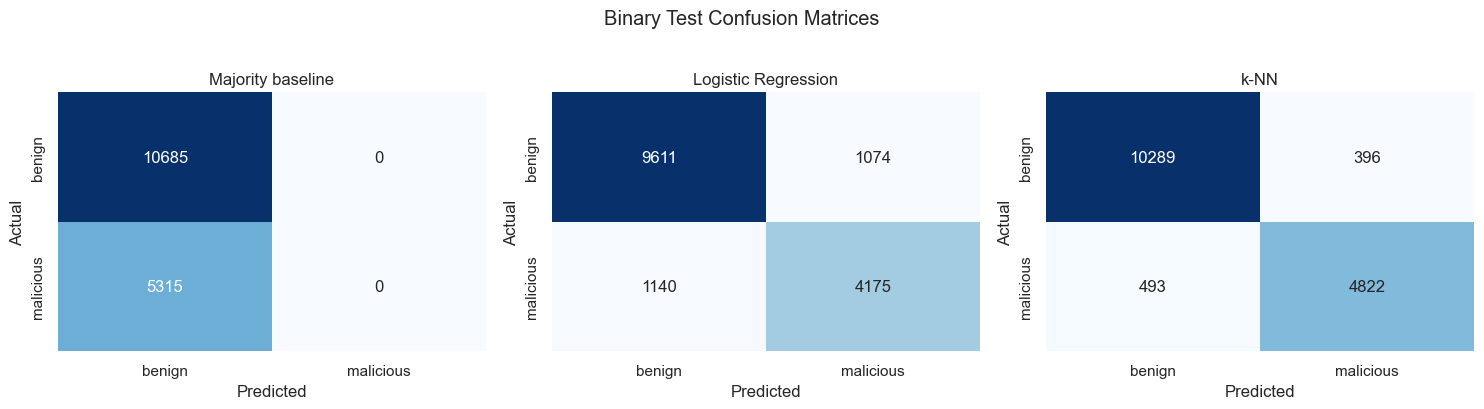

Test interpretation: k-NN achieved the best balanced accuracy (0.9351) on the held-out test set. The majority baseline performs poorly on the malicious class, which shows why plain accuracy would be misleading under class imbalance.
Course interpretation: logistic regression remains the main explanatory model because its coefficients can be interpreted directly, while k-NN serves as the predictive benchmark.


In [10]:
display(binary_results['cv_results'].groupby('model').head(3).reset_index(drop=True))
display(binary_results['test_metrics'])
plot_confusion_set(binary_results['confusion_matrices'], 'Binary Test Confusion Matrices')

best_binary = binary_results['test_metrics'].iloc[0]
print(
    f"Test interpretation: {best_binary['model']} achieved the best balanced accuracy "
    f"({best_binary['balanced_accuracy']:.4f}) on the held-out test set. "
    'The majority baseline performs poorly on the malicious class, which shows why plain accuracy would be misleading under class imbalance.'
)
print(
    'Course interpretation: logistic regression remains the main explanatory model because its coefficients can be interpreted directly, '
    'while k-NN serves as the predictive benchmark.'
)

In [11]:
display(binary_results['per_class_metrics'])

binary_coef = binary_results['logistic_coefficients'].copy()
display(binary_coef.head(12))

positive = binary_coef[binary_coef['coefficient'] > 0].head(5)['feature'].tolist()
negative = binary_coef[binary_coef['coefficient'] < 0].head(5)['feature'].tolist()
print(
    'Coefficient interpretation: in the logistic model, larger values of '
    + ', '.join(positive)
    + ' are associated with higher estimated odds of the URL being malicious.'
)
print(
    'Features pushing the model toward benign in this combined binary task include '
    + ', '.join(negative)
    + '. This does not prove these features are safe; it only describes associations in this dataset after combining phishing, malware, and defacement into one class.'
)
print(
    'Because numeric predictors were standardized, numeric coefficients are interpreted per one standard deviation increase. '
    'Binary indicators compare presence versus absence.'
)

,task,model,class,precision,recall,f1,support
0,binary_benign_vs_malicious,Majority baseline,benign,0.6678,1.0000,0.8008,10685
1,binary_benign_vs_malicious,Majority baseline,malicious,0.0000,0.0000,0.0000,5315
2,binary_benign_vs_malicious,Logistic Regression,benign,0.8940,0.8995,0.8967,10685
3,binary_benign_vs_malicious,Logistic Regression,malicious,0.7954,0.7855,0.7904,5315
4,binary_benign_vs_malicious,k-NN,benign,0.9543,0.9629,0.9586,10685
5,binary_benign_vs_malicious,k-NN,malicious,0.9241,0.9072,0.9156,5315


,class,feature,coefficient,abs_coefficient,odds_ratio,direction,unit
0,malicious,has_scheme,5.9056,5.9056,367.0949,positive,feature present vs absent
1,malicious,has_percent_encoding,-2.2193,2.2193,0.1087,negative,feature present vs absent
2,malicious,has_query,-1.6949,1.6949,0.1836,negative,feature present vs absent
3,malicious,path_length,-1.4932,1.4932,0.2246,negative,per 1 SD increase
4,malicious,token_login,-1.3126,1.3126,0.2691,negative,feature present vs absent
5,malicious,token_verify,1.2104,1.2104,3.3547,positive,feature present vs absent
6,malicious,subdomain_count,1.1696,1.1696,3.2206,positive,per 1 SD increase
7,malicious,has_at_symbol,1.1692,1.1692,3.2196,positive,feature present vs absent
8,malicious,url_length,0.9143,0.9143,2.4950,positive,per 1 SD increase
9,malicious,host_length,-0.7865,0.7865,0.4554,negative,per 1 SD increase


Coefficient interpretation: in the logistic model, larger values of has_scheme, token_verify, subdomain_count, has_at_symbol, url_length are associated with higher estimated odds of the URL being malicious.
Features pushing the model toward benign in this combined binary task include has_percent_encoding, has_query, path_length, token_login, host_length. This does not prove these features are safe; it only describes associations in this dataset after combining phishing, malware, and defacement into one class.
Because numeric predictors were standardized, numeric coefficients are interpreted per one standard deviation increase. Binary indicators compare presence versus absence.


## Multiclass Task: Benign, Phishing, Malware, Defacement

The multiclass task uses the same selected feature set and compares the same three models. Model tuning is still done with cross-validation on the training split, and the final report uses the untouched test split.

,task,model,mean_fit_time,param_model__C,param_model__class_weight,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,rank_test_balanced_accuracy,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro,param_model__n_neighbors,param_model__p,param_model__weights
0,multiclass_url_type,Logistic Regression,3.1525,10.0000,balanced,0.7657,0.0022,4,0.8015,0.0030,1,0.7251,0.0022,1,NaN,NaN,NaN
1,multiclass_url_type,Logistic Regression,1.7888,1.0000,balanced,0.7600,0.0026,5,0.7940,0.0031,2,0.7095,0.0032,2,NaN,NaN,NaN
2,multiclass_url_type,Logistic Regression,1.0665,0.1000,balanced,0.7580,0.0015,6,0.7836,0.0052,3,0.7003,0.0024,3,NaN,NaN,NaN
3,multiclass_url_type,k-NN,0.0675,NaN,NaN,0.9247,0.0020,1,0.8762,0.0025,1,0.8859,0.0035,1,5.0000,1.0000,distance
4,multiclass_url_type,k-NN,0.0824,NaN,NaN,0.9243,0.0022,2,0.8715,0.0036,3,0.8839,0.0038,2,11.0000,1.0000,distance
5,multiclass_url_type,k-NN,0.1826,NaN,NaN,0.9227,0.0026,4,0.8738,0.0035,2,0.8826,0.0045,3,5.0000,2.0000,distance


,task,model,accuracy,balanced_accuracy,macro_f1,precision,recall,f1
0,multiclass_url_type,k-NN,0.9270,0.8795,0.8911,0.9048,0.8795,0.8911
1,multiclass_url_type,Logistic Regression,0.7644,0.7958,0.7251,0.6888,0.7958,0.7251
2,multiclass_url_type,Majority baseline,0.6678,0.2500,0.2002,0.1670,0.2500,0.2002


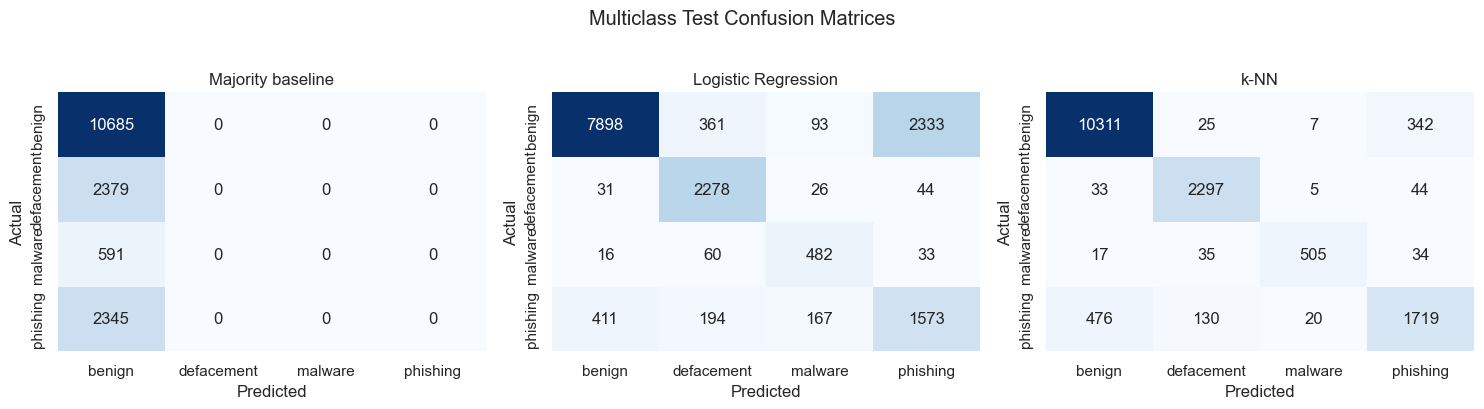

Test interpretation: k-NN was strongest on the multiclass task with macro F1 = 0.8911. Macro F1 is emphasized here because the malware class is much smaller than the benign class.


In [12]:
display(multiclass_results['cv_results'].groupby('model').head(3).reset_index(drop=True))
display(multiclass_results['test_metrics'])
plot_confusion_set(multiclass_results['confusion_matrices'], 'Multiclass Test Confusion Matrices')

best_multi = multiclass_results['test_metrics'].iloc[0]
print(
    f"Test interpretation: {best_multi['model']} was strongest on the multiclass task with macro F1 = {best_multi['macro_f1']:.4f}. "
    'Macro F1 is emphasized here because the malware class is much smaller than the benign class.'
)

In [13]:
display(multiclass_results['per_class_metrics'])

knn_multiclass = multiclass_results['per_class_metrics'].query("model == 'k-NN'").sort_values('f1')
logistic_multiclass = multiclass_results['per_class_metrics'].query("model == 'Logistic Regression'").sort_values('f1')
print(
    f"Hardest class for logistic regression: {logistic_multiclass.iloc[0]['class']} "
    f"(F1 = {logistic_multiclass.iloc[0]['f1']:.4f})."
)
print(
    f"Hardest class for k-NN: {knn_multiclass.iloc[0]['class']} "
    f"(F1 = {knn_multiclass.iloc[0]['f1']:.4f})."
)
print(
    'Interpretation: phishing is the most difficult subtype, which suggests its lexical patterns overlap more with benign and defacement URLs than the malware or defacement patterns do.'
)

,task,model,class,precision,recall,f1,support
0,multiclass_url_type,Majority baseline,benign,0.6678,1.0000,0.8008,10685
1,multiclass_url_type,Majority baseline,defacement,0.0000,0.0000,0.0000,2379
2,multiclass_url_type,Majority baseline,malware,0.0000,0.0000,0.0000,591
3,multiclass_url_type,Majority baseline,phishing,0.0000,0.0000,0.0000,2345
4,multiclass_url_type,Logistic Regression,benign,0.9452,0.7392,0.8296,10685
5,multiclass_url_type,Logistic Regression,defacement,0.7874,0.9575,0.8642,2379
6,multiclass_url_type,Logistic Regression,malware,0.6276,0.8156,0.7093,591
7,multiclass_url_type,Logistic Regression,phishing,0.3949,0.6708,0.4972,2345
8,multiclass_url_type,k-NN,benign,0.9515,0.9650,0.9582,10685
9,multiclass_url_type,k-NN,defacement,0.9236,0.9655,0.9441,2379


Hardest class for logistic regression: phishing (F1 = 0.4972).
Hardest class for k-NN: phishing (F1 = 0.7667).
Interpretation: phishing is the most difficult subtype, which suggests its lexical patterns overlap more with benign and defacement URLs than the malware or defacement patterns do.


In [14]:
multiclass_coef = multiclass_results['logistic_coefficients']
top_multiclass = multiclass_coef.groupby('class').head(6).reset_index(drop=True)
display(top_multiclass)

for class_name, group in top_multiclass.groupby('class'):
    features = ', '.join(group['feature'].head(4).tolist())
    print(f"{class_name}: top positive logistic signals include {features}.")

print(
    'These coefficients show which features move the model toward each class relative to the others, but they do not establish causality. '
    'They should be read as conditional associations inside this lexical feature set.'
)

,class,feature,coefficient,abs_coefficient,odds_ratio,direction,unit
0,benign,url_length,10.8070,10.8070,"49,363.1261",positive,per 1 SD increase
1,benign,has_scheme,-10.3198,10.3198,0.0000,negative,feature present vs absent
2,benign,query_length,-8.1490,8.1490,0.0003,negative,per 1 SD increase
3,benign,path_length,-6.1788,6.1788,0.0021,negative,per 1 SD increase
4,benign,token_verify,6.1695,6.1695,477.9628,positive,feature present vs absent
5,benign,token_secure,3.7028,3.7028,40.5588,positive,feature present vs absent
6,defacement,url_length,-69.5943,69.5943,0.0000,negative,per 1 SD increase
7,defacement,query_length,53.0884,53.0884,"113,757,526,545,429,688,221,696.0000",positive,per 1 SD increase
8,defacement,path_length,43.6027,43.6027,"8,637,633,361,596,234,752.0000",positive,per 1 SD increase
9,defacement,has_scheme,24.3271,24.3271,"36,739,462,762.5121",positive,feature present vs absent


benign: top positive logistic signals include url_length, has_scheme, query_length, path_length.
defacement: top positive logistic signals include url_length, query_length, path_length, has_scheme.
malware: top positive logistic signals include url_length, query_length, path_length, host_length.
phishing: top positive logistic signals include url_length, query_length, path_length, has_scheme.
These coefficients show which features move the model toward each class relative to the others, but they do not establish causality. They should be read as conditional associations inside this lexical feature set.


## What The Models Suggest, and What They Do Not Prove

- The lexical features carry enough signal for strong classification, especially for k-NN.
- Logistic regression is noticeably weaker than k-NN on prediction, but it is much easier to interpret and defend in a statistics course report.
- The phishing class is the hardest to separate, so any single-number accuracy summary would hide an important modelling weakness.
- Small validation gains from suspicious-token features suggest that most predictive signal is already captured by the core lexical structure.
- These models do **not** prove causal relationships. They only show associations in this labelled dataset.
- Results remain sensitive to dataset composition, source bias, label quality, and the decision to use a stratified modelling sample for tractability.
- The workflow is reproducible, but it is still lexical-only. It does not use page content, DNS data, WHOIS data, or temporal drift checks.